# LLM confidence calibration on tweet irony detection

This notebook measures how much you can trust an LLM's *self-reported* confidence on a
binary classification task. The task is **irony detection**: given a tweet, decide whether
it is ironic (1) or not (0). We use the SemEval-2018 Task 3 split distributed in
`cardiffnlp/tweet_eval`.

For each example we ask the model for a label **and** a confidence (0–100) that its own
label is correct. We then check two separate properties:

- **Calibration** — does a stated confidence of *c* correspond to being right about *c* of
  the time? Summarised by **ECE** (expected calibration error) and a reliability diagram.
- **Discrimination** — does higher confidence rank correct predictions above wrong ones,
  regardless of absolute magnitude? Summarised by **AUROC** of confidence vs correctness.

These are independent: a model can be well-calibrated but useless at discrimination, or
badly calibrated yet perfectly ranked (the latter is fixable by post-hoc recalibration).

## Setup

Requires an `ANTHROPIC_API_KEY` environment variable. Install dependencies if needed:

In [1]:
# !pip install datasets anthropic scikit-learn numpy matplotlib

In [ ]:
import os
import re
import csv
import json
import time

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# config
MODEL = "claude-haiku-4-5-20251001"  # cheap classification tier; irony is hard
                                     # enough that even haiku gives a wide
                                     # confidence spread to study
N_SAMPLES = 4601       # subsample size; drawn from the pooled train+val+test
                       # (4601 examples total)
N_BINS = 30            # number of equal-width bins between min and max
                       # confidence for ece / reliability
SEED = 0
RESULTS_CSV = "irony_haiku_100.csv"

assert os.environ.get("ANTHROPIC_API_KEY"), "set ANTHROPIC_API_KEY before running"
rng = np.random.default_rng(SEED)

## Load the data

We use `cardiffnlp/tweet_eval` with the `irony` config — the SemEval-2018 Task 3 split,
repackaged for HuggingFace. Notes:

- All splits (train / validation / test) ship with real labels and Claude is evaluated
  zero-shot, so the train/val/test distinction doesn't matter for our purposes. We
  concatenate all three (4601 examples) and subsample from the pool — more data means
  tighter ECE estimates and more bins surviving the quantile dedupe.
- Label convention: `1` = ironic, `0` = not ironic. "Ironic" in this dataset is a broad
  category that includes verbal irony, situational irony, and sarcasm.
- The `text` field holds the tweet. Tweets contain `@user` mentions, `{{URL}}`-style URL
  placeholders, and hashtags — we feed them through as-is.

In [2]:
from datasets import load_dataset, concatenate_datasets

# zero-shot eval, so train/val/test are interchangeable — pool them all for more data
splits = load_dataset("cardiffnlp/tweet_eval", "irony")
ds = concatenate_datasets([splits["train"], splits["validation"], splits["test"]])
print(ds)
print(ds[0])

# subsample for cost/time control
n = min(N_SAMPLES, len(ds))
sample_idx = rng.choice(len(ds), size=n, replace=False)
samples = [ds[int(i)] for i in sample_idx]
print(f"\nusing {len(samples)} examples (from a pool of {len(ds)})")
print(f"base rate (fraction ironic): {np.mean([s['label'] for s in samples]):.3f}")

/Users/aaron/.pyenv/versions/llm_confidence/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset({
    features: ['text', 'label'],
    num_rows: 4601
})
{'text': 'seeing ppl walking w/ crutches makes me really excited for the next 3 weeks of my life', 'label': 1}

using 4601 examples (from a pool of 4601)
base rate (fraction ironic): 0.481


## Classify with verbalized confidence

The prompt asks for a JSON object with a label and a confidence that the label is correct.
Confidence is interpreted as the model's stated **P(its prediction is correct)**, which is
exactly what the calibration and AUROC checks below evaluate against actual correctness.

The system prompt includes a short rubric for "ironic" (sarcasm / verbal / situational)
because irony is fuzzier than e.g. grammaticality — without a rubric the model can drift
toward a stricter or looser definition than the dataset annotators used, which would just
look like miscalibration in the results.

`temperature=0` makes the prediction deterministic per input. Parsing is defensive: if the
model returns something unparseable, the row is dropped rather than guessed.

> **Logprob alternative.** If you move to a provider that exposes token logprobs, replace
> the verbalized confidence with the probability mass the model puts on the `ironic` vs
> `not ironic` answer token (constrain the answer to a single token first, so the mass
> isn't smeared across phrasings). Everything downstream is unchanged.

In [3]:
from anthropic import Anthropic

client = Anthropic()  # reads ANTHROPIC_API_KEY from the environment

SYSTEM = (
    "You judge whether tweets are ironic. A tweet is IRONIC if its intended meaning "
    "differs from a literal reading — this includes sarcasm, verbal irony (saying the "
    "opposite of what is meant), and situational irony (an outcome contrary to expectation). "
    "A tweet is NOT IRONIC if it is meant literally, even if it is negative, funny, or "
    "exaggerated. Respond with ONLY a JSON object and nothing else, in the form "
    '{"label": <1 for ironic, 0 for not ironic>, "confidence": <integer 0-100 = your '
    "probability that your label is correct>}."
)

_json_re = re.compile(r"\{.*\}", re.DOTALL)


def classify_text(text, max_retries=3):
    """classify one tweet and return its self-reported confidence.

    :param text: the tweet text to judge.
    :param max_retries: number of attempts on transient api/parse failures.
    :returns: tuple (label, confidence) with label in {0, 1} and confidence in
        [0, 1], or (None, None) if the response could not be parsed.
    """
    for attempt in range(max_retries):
        try:
            resp = client.messages.create(
                model=MODEL,
                max_tokens=40,
                temperature=0,
                system=SYSTEM,
                messages=[{"role": "user", "content": text}],
            )
            body = resp.content[0].text
            match = _json_re.search(body)
            if not match:
                return None, None
            obj = json.loads(match.group(0))
            label = int(obj["label"])
            conf = float(obj["confidence"]) / 100.0  # to [0, 1]
            if label not in (0, 1) or not (0.0 <= conf <= 1.0):
                return None, None
            return label, conf
        except Exception:
            # back off briefly on rate limits / transient errors
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
    return None, None

In [ ]:
results = []  # rows: {text, true_label, pred_label, confidence, correct}

for i, ex in enumerate(samples):
    pred, conf = classify_text(ex["text"])
    if pred is None:
        continue
    results.append({
        "text": ex["text"],
        "true_label": ex["label"],
        "pred_label": pred,
        "confidence": conf,
        "correct": int(pred == ex["label"]),
    })
    if (i + 1) % 100 == 0:
        print(f"{i + 1}/{len(samples)} done")

print(f"\nparsed {len(results)} / {len(samples)} responses")

# cache so you can re-analyze without re-calling the api
with open(RESULTS_CSV, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["text", "true_label", "pred_label",
                                      "confidence", "correct"])
    w.writeheader()
    w.writerows(results)

confidence = np.array([r["confidence"] for r in results])
correct = np.array([r["correct"] for r in results])
accuracy = correct.mean()
print(f"accuracy: {accuracy:.3f}")

25/4601 done
50/4601 done
75/4601 done
100/4601 done
125/4601 done
150/4601 done
175/4601 done
200/4601 done
225/4601 done
250/4601 done
275/4601 done
300/4601 done
325/4601 done
350/4601 done
375/4601 done
400/4601 done
425/4601 done
450/4601 done
475/4601 done
500/4601 done
525/4601 done
550/4601 done
575/4601 done
600/4601 done
625/4601 done
650/4601 done
675/4601 done
700/4601 done
725/4601 done
750/4601 done
775/4601 done
800/4601 done
825/4601 done
850/4601 done
875/4601 done
900/4601 done
925/4601 done
950/4601 done
975/4601 done
1000/4601 done
1025/4601 done
1050/4601 done
1075/4601 done
1100/4601 done
1125/4601 done
1150/4601 done
1175/4601 done
1200/4601 done
1225/4601 done
1250/4601 done
1275/4601 done
1300/4601 done
1325/4601 done
1350/4601 done
1375/4601 done
1400/4601 done
1425/4601 done
1450/4601 done
1475/4601 done
1500/4601 done
1525/4601 done
1550/4601 done
1575/4601 done
1600/4601 done
1625/4601 done
1650/4601 done
1675/4601 done
1700/4601 done
1725/4601 done
1750/46

## Metrics: ECE, reliability diagram, AUROC

ECE is the average gap, per confidence bin, between mean stated confidence and empirical
accuracy, weighted by bin population. The reliability diagram plots the same bins; the 45°
line is perfect calibration, points below it are overconfidence. AUROC asks whether
confidence ranks correct predictions above incorrect ones (0.5 = no signal).

**Binning.** We use **`N_BINS` equal-width bins between `min(confidence)` and
`max(confidence)`** (`strategy="range"`). Bins are uniformly spaced, easy to read, and
none are wasted on the empty regions outside the observed range. Two alternatives are
available if you want them: `strategy="quantile"` puts roughly equal counts in every bin
(better when the data is heavily concentrated, but bin widths are unequal); `strategy=
"uniform"` uses equal-width bins over the full `[0, 1]` interval, which is comparable
across runs but typically leaves several bins empty.

**Error bars.** Each bin's empirical accuracy is a noisy estimate from a finite number of
trials. We overlay 95% Wilson score intervals so you can see which apparent
miscalibrations are real and which are small-bin noise.

In [12]:
def expected_calibration_error(confidences, correct, n_bins=10, strategy="range"):
    """compute expected calibration error.

    :param confidences: stated probability the prediction is correct, in [0, 1].
    :param correct: 0/1 flags, 1 where the prediction matched the label.
    :param n_bins: target number of bins.
    :param strategy: binning scheme.
        "range" (default): n equal-width bins between min(confidence) and
            max(confidence). bins are uniform width and concentrated where
            data actually lives.
        "quantile": n equal-count bins. tightest per-bin uncertainty but
            unequal bin widths.
        "uniform": n equal-width bins on [0, 1]. easy to compare across runs
            but wastes bins on empty regions.
    :returns: tuple (ece, stats) where stats holds per-bin edges, mean
        confidence, accuracy and count for plotting.
    """
    confidences = np.asarray(confidences, dtype=float)
    correct = np.asarray(correct, dtype=float)

    if strategy == "uniform":
        edges = np.linspace(0.0, 1.0, n_bins + 1)
    elif strategy == "range":
        lo, hi = float(confidences.min()), float(confidences.max())
        # degenerate case: all confidences identical
        if hi == lo:
            edges = np.array([lo, lo + 1e-12])
        else:
            edges = np.linspace(lo, hi, n_bins + 1)
    elif strategy == "quantile":
        # equal-count edges; dedupe to avoid zero-width bins on ties
        edges = np.unique(np.quantile(confidences, np.linspace(0.0, 1.0, n_bins + 1)))
    else:
        raise ValueError(f"unknown strategy: {strategy!r}")

    n_actual = len(edges) - 1
    # clip so confidences equal to the upper edge land in the last bin
    idx = np.clip(np.digitize(confidences, edges) - 1, 0, n_actual - 1)

    bin_conf, bin_acc, bin_count = [], [], []
    ece, total = 0.0, len(confidences)
    for b in range(n_actual):
        mask = idx == b
        count = int(mask.sum())
        bin_count.append(count)
        if count == 0:
            bin_conf.append(np.nan)
            bin_acc.append(np.nan)
            continue
        mean_conf = confidences[mask].mean()
        acc = correct[mask].mean()
        bin_conf.append(mean_conf)
        bin_acc.append(acc)
        ece += (count / total) * abs(mean_conf - acc)
    return ece, {
        "edges": edges,
        "mean_confidence": np.array(bin_conf),
        "accuracy": np.array(bin_acc),
        "count": np.array(bin_count),
    }


def wilson_interval(k, n, z=1.96):
    """wilson score interval for a binomial proportion.

    more honest than the normal approximation at small n or extreme p, which
    is exactly the regime each calibration bin sits in.

    :param k: number of successes.
    :param n: number of trials.
    :param z: z-score for the confidence level (1.96 ≈ 95%).
    :returns: (lower, upper) bounds; (nan, nan) if n == 0.
    """
    if n == 0:
        return np.nan, np.nan
    p = k / n
    denom = 1.0 + z ** 2 / n
    center = (p + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return center - half, center + half


ece, stats = expected_calibration_error(confidence, correct, n_bins=N_BINS)
auroc = roc_auc_score(correct, confidence) if len(np.unique(correct)) > 1 else float("nan")
print(f"accuracy: {accuracy:.3f}")
print(f"ECE:      {ece:.3f}  ({len(stats['edges']) - 1} equal-width bins over "
      f"[{stats['edges'][0]:.2f}, {stats['edges'][-1]:.2f}])")
print(f"AUROC:    {auroc:.3f}  (discrimination; 0.5 = confidence is noise)")

accuracy: 0.756
ECE:      0.094  (30 equal-width bins over [0.42, 0.95])
AUROC:    0.655  (discrimination; 0.5 = confidence is noise)


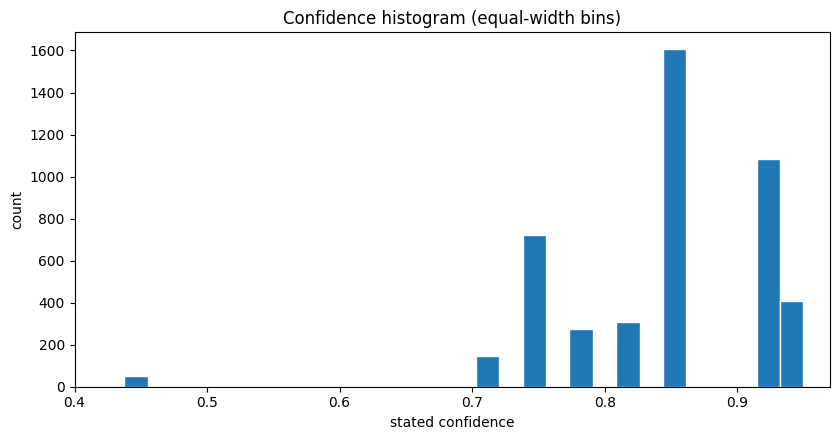

In [22]:
# confidence histogram using the same equal-width bin edges as the reliability
# diagram, so visually the bars line up with the points above
edges = stats["edges"]
counts = stats["count"]
widths = np.diff(edges)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(edges[:-1], counts, width=widths, align="edge", edgecolor="white")
ax.set_xlabel("stated confidence")
ax.set_ylabel("count")
ax.set_title("Confidence histogram (equal-width bins)")
ax.set_xlim(edges[0] - 0.02, min(1.0, edges[-1] + 0.02))
plt.tight_layout()
plt.show()

In [18]:
# raw value counts — what discrete confidences does the model actually emit?
# more granular than the histogram (which bins them) and a useful sanity check
# on whether the model uses the full 0-100 scale or sticks to a few values
conf_ints = np.round(confidence * 100).astype(int)
uniq, cnt = np.unique(conf_ints, return_counts=True)
print(f"{len(uniq)} unique stated confidence values:")
for c, n in zip(uniq, cnt):
    print(f"  {c:3d}: {n:5d}")

9 unique stated confidence values:
   42:     1
   45:    51
   72:   146
   75:   721
   78:   274
   82:   306
   85:  1606
   92:  1082
   95:   409


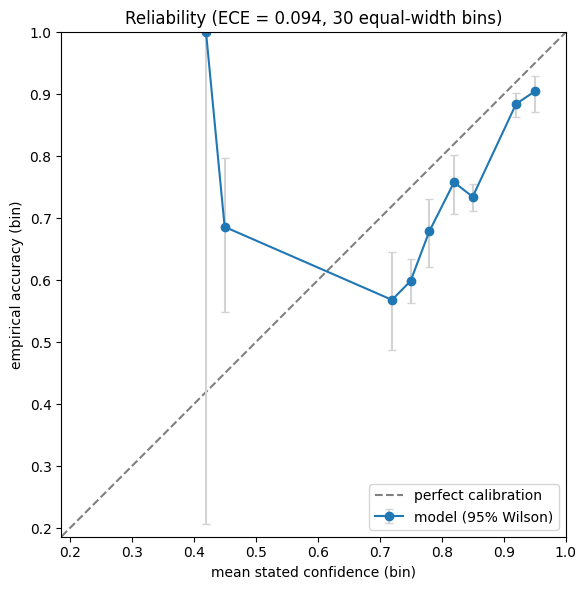

In [21]:
# reliability diagram with equal-width bins over [min, max] and wilson 95%
# intervals on each bin's empirical accuracy
edges = stats["edges"]
mean_conf = stats["mean_confidence"]
acc = stats["accuracy"]
counts = stats["count"]

lowers = np.full_like(acc, np.nan)
uppers = np.full_like(acc, np.nan)
for i, (a, c) in enumerate(zip(acc, counts)):
    if c == 0 or np.isnan(a):
        continue
    lowers[i], uppers[i] = wilson_interval(a * c, c)

valid = ~np.isnan(acc)
yerr = np.vstack([acc - lowers, uppers - acc])

# zoom both axes to a shared range covering the data + ci, with small padding;
# keeping axes equal preserves the meaning of the 45° line
lo = min(np.nanmin(mean_conf[valid]), np.nanmin(lowers[valid])) - 0.02
hi = max(np.nanmax(mean_conf[valid]), np.nanmax(uppers[valid]), 1.0) + 0.01
lo = max(0.0, lo)
hi = min(1.0, hi)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
ax.errorbar(
    mean_conf[valid], acc[valid], yerr=yerr[:, valid],
    fmt="o-", capsize=3, ecolor="lightgray", label="model (95% Wilson)",
)
ax.set_xlabel("mean stated confidence (bin)")
ax.set_ylabel("empirical accuracy (bin)")
ax.set_title(f"Reliability (ECE = {ece:.3f}, {len(edges) - 1} equal-width bins)")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()